In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
df=pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
#drop month day and year
df.drop(['day', 'month','year'], axis=1, inplace=True)

In [6]:
##encoding
df['Classes']=np.where(df['Classes'].str.contains("not fires"),0,1)

In [7]:
df['Classes'].value_counts()

Classes
1    243
0      1
Name: count, dtype: int64

In [8]:
## independent and dependent features

x=df.drop('FWI', axis=1)
y=df['FWI']

In [9]:
df['Classes'].value_counts()

Classes
1    243
0      1
Name: count, dtype: int64

In [10]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
239    6.5
240    0.0
241    0.2
242    0.7
243    0.5
Name: FWI, Length: 244, dtype: float64

In [11]:
## train test split 

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25, random_state=42)

In [12]:
x_train.shape,x_test.shape

((183, 11), (61, 11))

In [13]:
## feature selection basedd on correlation 
x_train.corr()
#if the 2 features are highly correlated like 90 or 95 percent then one of them can be droped as they are same. they act like same feature. the percentage of that feature will be decided by domain expert that how much percent.
## if f1 related to f2 and f3 related to f3 then f2 cqn be drped. **multicolinearity 

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.664492,-0.249312,-0.375047,0.703238,0.485379,0.374673,0.609525,0.458575,-0.098727,0.256099
RH,-0.664492,1.000000,0.235766,0.262550,-0.637201,-0.398168,-0.215075,-0.694976,-0.344365,0.129033,-0.397053
Ws,-0.249312,0.235766,1.000000,0.262759,-0.169489,-0.013533,0.073923,0.015384,0.022529,-0.067609,-0.229797
Rain,-0.375047,0.262550,0.262759,1.000000,-0.585018,-0.291338,-0.296114,-0.353219,-0.301347,0.021330,-0.096985
FFMC,0.703238,-0.637201,-0.169489,-0.585018,1.000000,0.602278,0.508348,0.744270,0.592841,-0.058605,0.237434
DMC,0.485379,-0.398168,-0.013533,-0.291338,0.602278,1.000000,0.877045,0.652894,0.981876,0.010693,0.197489
DC,0.374673,-0.215075,0.073923,-0.296114,0.508348,0.877045,1.000000,0.496563,0.941248,0.053430,-0.079217
ISI,0.609525,-0.694976,0.015384,-0.353219,0.744270,0.652894,0.496563,1.000000,0.624038,-0.138950,0.267027
BUI,0.458575,-0.344365,0.022529,-0.301347,0.592841,0.981876,0.941248,0.624038,1.000000,0.032527,0.092548
Classes,-0.098727,0.129033,-0.067609,0.021330,-0.058605,0.010693,0.053430,-0.138950,0.032527,1.000000,-0.073721


<Axes: >

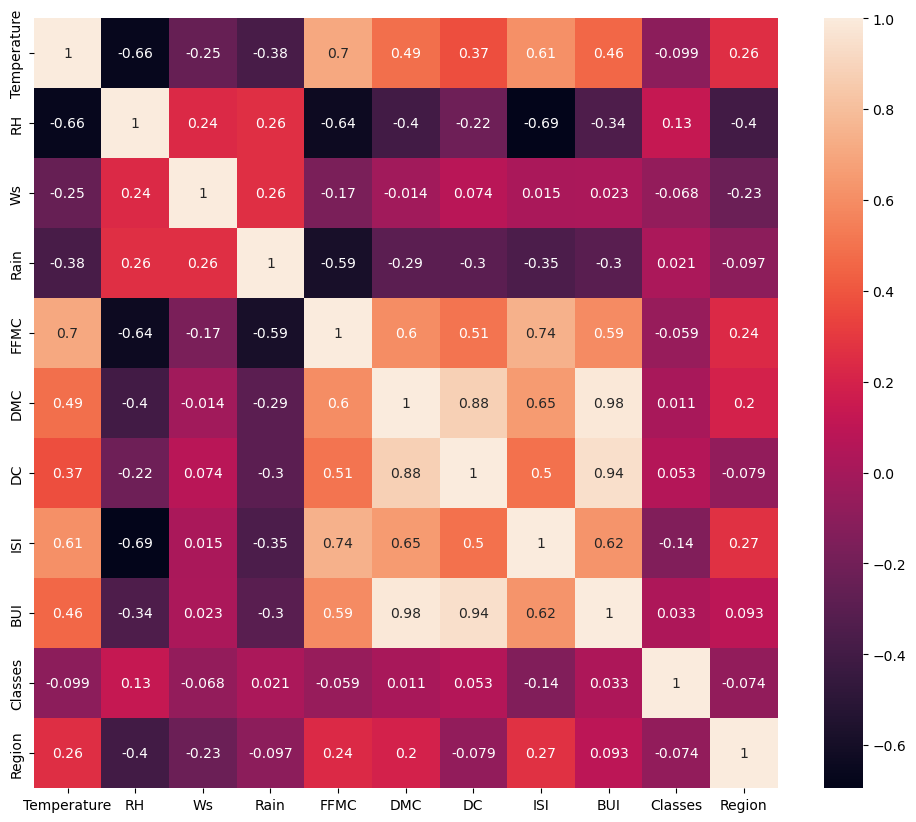

In [14]:
## check for multicollinearlity

plt.figure(figsize=(12,10))
corr=x_train.corr()
sns.heatmap(corr, annot=True)

In [15]:
#to get the feature based on threashold value and based on that to add or remove the feature
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [16]:
#setting the threshold by domain expert
corr_features=correlation(x_train,0.85)

In [17]:
#these are the correlated features
corr_features

{'BUI', 'DC'}

In [18]:
##drop features when coorelation is more than 0.85
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)
x_train.shape,x_test.shape

((183, 9), (61, 9))

## Features scalling or standardization 


In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [20]:
x_train_scaled

array([[-0.81085018,  0.16311382,  1.29231566, ..., -0.773495  ,
         0.07412493, -1.00547949],
       [ 1.06405791, -0.44884168,  0.15167049, ...,  0.83939993,
         0.07412493,  0.99455037],
       [-0.27516216,  0.63907922, -0.60875963, ..., -0.21981465,
         0.07412493,  0.99455037],
       ...,
       [-1.88222624,  0.91105944,  0.53188555, ..., -1.08644476,
         0.07412493, -1.00547949],
       [ 0.26052587, -0.38084663,  0.15167049, ...,  0.47830405,
         0.07412493,  0.99455037],
       [-0.54300617,  0.9790545 ,  2.05274578, ..., -0.86978723,
         0.07412493, -1.00547949]], shape=(183, 9))

## boxplots to understand effect of standard scaler

Text(0.5, 1.0, 'x_train after scaling')

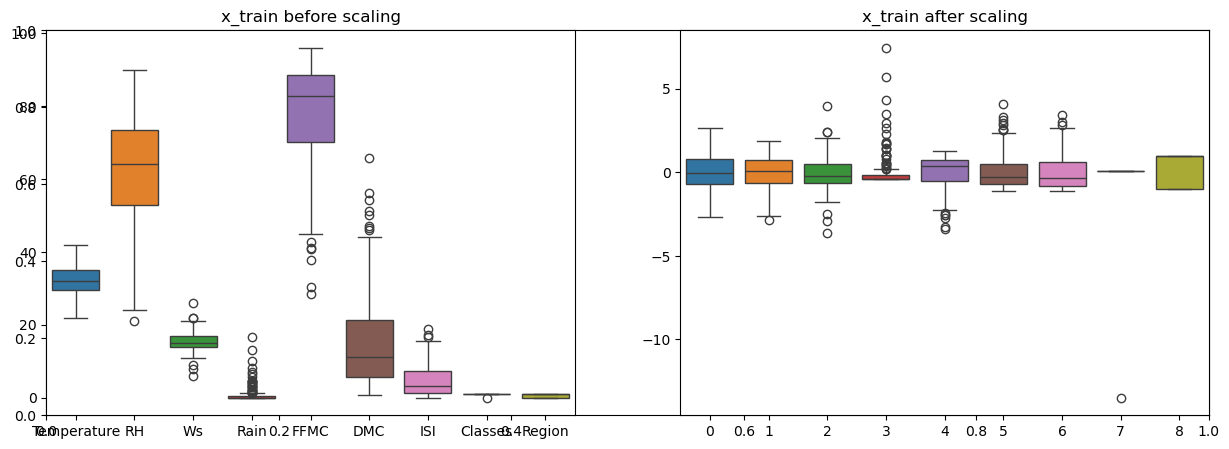

In [21]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')

plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train after scaling')

## linear regression model

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)

ValueError: Input y contains NaN.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Remove the single row with NaN value from existing variables
mask = ~pd.isna(y_train)  # Create mask to identify non-NaN values
x_train_scaled = x_train_scaled[mask]  # Remove corresponding row from features
y_train = y_train[mask]  # Remove NaN value from target

linreg = LinearRegression()
linreg.fit(x_train_scaled, y_train)  # Now uses existing variables without NaN
y_pred = linreg.predict(x_test_scaled)

mean absolute error 0.5789199889810827
r2 score 0.9904114636838083


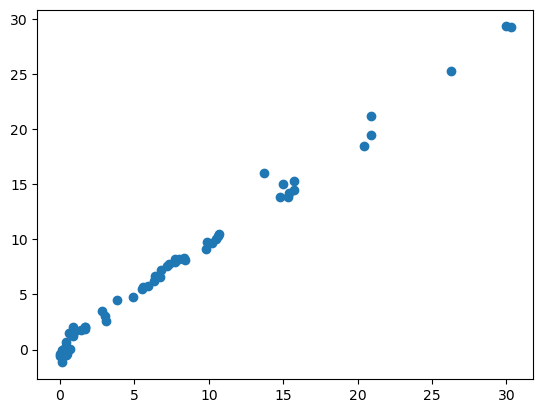

In [24]:
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )
plt.scatter(y_test,y_pred)

## lasso regression 

mean absolute error 1.1862264635407112
r2 score 0.9527953643007689


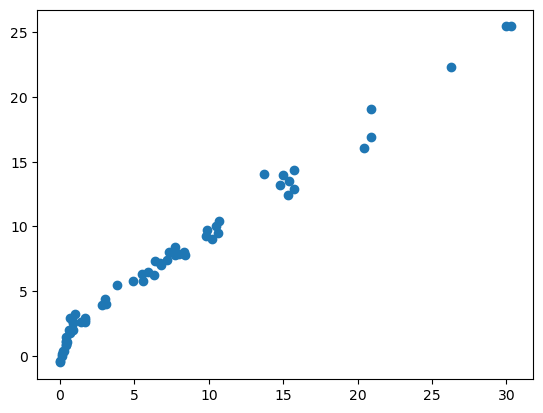

In [25]:
## lasso regression 
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )
plt.scatter(y_test,y_pred)

Cross validation lasso

In [26]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [27]:
lassocv.predict(x_test_scaled) ## can use for prediction also 

array([ 8.1020454 ,  7.61101366,  6.7700559 ,  5.88177569, 13.86155555,
        1.5626065 , 10.55068702, -1.227137  ,  2.05206713, -0.35543097,
        0.74972636,  4.60503228,  2.15025056,  1.77760447, 18.39801677,
        6.59715013, 25.16738144, -0.571483  ,  7.18161676,  4.82667554,
        2.10419573,  0.27791535,  7.992688  ,  0.27778995, 21.16633074,
       -0.17724724,  5.70238555,  9.67335895,  3.2314047 , 14.99063925,
        8.33166663, -0.4526736 , 10.31316084, 14.40369708,  1.83520817,
        1.80551599,  1.28555126,  5.57496055, -0.41082122, -0.49719793,
        6.26114813,  2.68218671,  3.54441176, -0.75232594, 15.32881903,
        8.25452059,  8.21460026,  1.49798829, 10.10619619,  9.13587763,
       29.13464821,  1.86386588,  7.73916899, 19.3274538 , 13.85115349,
       15.94556884, 29.17063725,  0.12723419, -0.30958297, 14.27662414,
        9.79357385])

In [28]:
lassocv.alpha_

np.float64(0.01901418748359191)

In [29]:
lassocv.alphas_

array([6.67624579, 6.22628917, 5.80665812, 5.4153088 , 5.05033511,
       4.70995942, 4.39252392, 4.09648251, 3.8203933 , 3.56291158,
       3.32278326, 3.09883879, 2.88998743, 2.69521195, 2.51356368,
       2.3441579 , 2.18616951, 2.038829  , 1.90141875, 1.77326949,
       1.65375706, 1.54229937, 1.43835355, 1.34141334, 1.25100657,
       1.16669291, 1.08806172, 1.01473   , 0.94634059, 0.8825604 ,
       0.82307879, 0.76760603, 0.71587195, 0.66762458, 0.62262892,
       0.58066581, 0.54153088, 0.50503351, 0.47099594, 0.43925239,
       0.40964825, 0.38203933, 0.35629116, 0.33227833, 0.30988388,
       0.28899874, 0.26952119, 0.25135637, 0.23441579, 0.21861695,
       0.2038829 , 0.19014187, 0.17732695, 0.16537571, 0.15422994,
       0.14383536, 0.13414133, 0.12510066, 0.11666929, 0.10880617,
       0.101473  , 0.09463406, 0.08825604, 0.08230788, 0.0767606 ,
       0.0715872 , 0.06676246, 0.06226289, 0.05806658, 0.05415309,
       0.05050335, 0.04709959, 0.04392524, 0.04096483, 0.03820

In [30]:
lassocv.mse_path_

array([[62.50911403, 40.52488136, 54.70970825, 72.93519208, 36.85263242],
       [59.85615347, 35.73721738, 49.87188973, 69.6526798 , 32.36204761],
       [52.75091968, 31.55315187, 43.55628575, 63.49483183, 28.43613517],
       [46.50089369, 27.89544926, 37.96703277, 58.05520766, 24.43138089],
       [41.03442778, 24.69674979, 33.10910227, 53.24590859, 21.02645102],
       [36.25144756, 21.89851039, 28.88722951, 48.99010399, 18.13831016],
       [32.06472052, 19.4496272 , 25.21824538, 44.96554774, 15.69450725],
       [28.39863709, 17.30556605, 22.02975795, 39.7151188 , 13.63257336],
       [25.18692568, 15.42767334, 19.25934405, 35.1243426 , 11.89824832],
       [22.37196335, 13.78211586, 16.85220121, 31.10871014, 10.44534253],
       [19.90352752, 12.3394581 , 14.76084973, 27.59484553,  9.23323572],
       [17.73783914, 11.07404293, 12.94400524, 24.5188267 ,  8.22708866],
       [15.83658279,  9.96350309, 11.36577097, 21.82496085,  7.39683434],
       [14.16678855,  8.98833627,  9.9

mean absolute error 0.5981394079155379
r2 score 0.9898722785030937


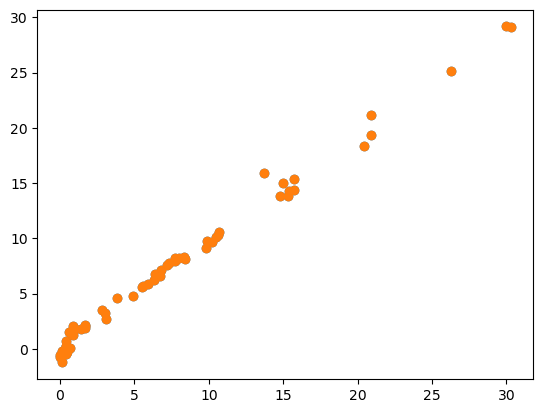

In [31]:
y_pred = lassocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)

mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )
plt.scatter(y_test,y_pred)

ridge regression 

mean absolute error 0.5956617266266321
r2 score 0.9899021194269711


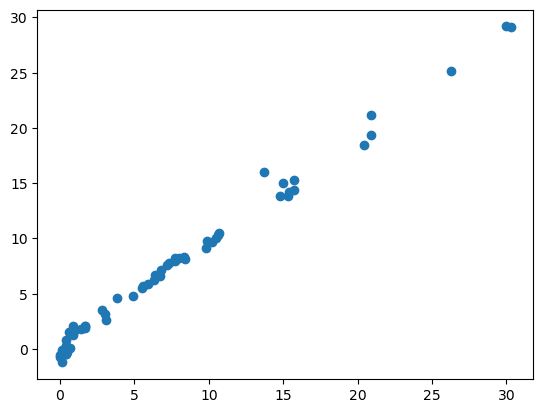

In [32]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )
plt.scatter(y_test,y_pred)

mean absolute error 0.5956617266266321
r2 score 0.9899021194269711


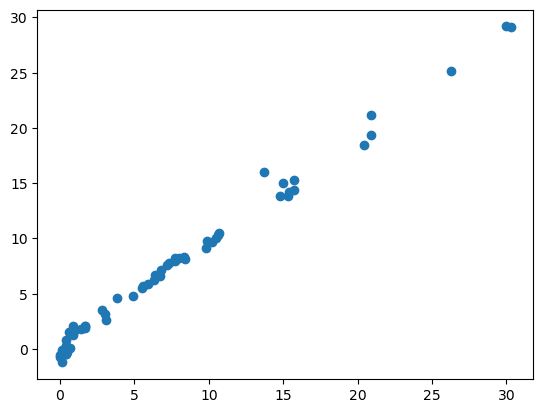

In [33]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)

mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )

Elastic net regression 

mean absolute error 1.9548604403609704
r2 score 0.8774765281630915


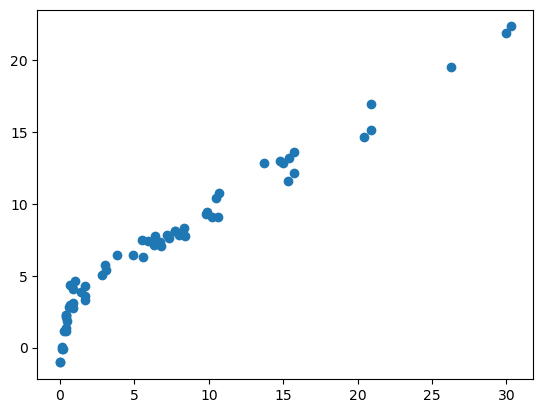

In [34]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred )
print("mean absolute error", mae)
print("r2 score", score )
plt.scatter(y_test,y_pred)

In [35]:
## pickle the machine learning model, preprocessing model standardscaler

In [36]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [37]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [38]:
import pickle 
pickle.dump(scaler,open('scaler.pkl', 'wb'))
pickle.dump(ridge,open('ridge.pkl', 'wb'))

SyntaxError: invalid syntax (15193383.py, line 1)